In [2]:
print("hellow World")

hellow World


# ２章「確率分布と統計モデルの最尤推定」

VSCodeの左下の”アウトライン”で見出し見れます！

[pythonh写経サイト](https://note.com/e_dao/n/n3db34a5c3685)

# 1.データ確認＝分布の確認

## ライブラリインポート

In [3]:
# 数値計算
import math
import numpy as np
import pandas as pd

# 統計計算
import scipy.stats as stats

# Rデータ読み込み
import rdata

# 可視化
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Meiryo'

## データ読み込み＆平均/分散/偏差のチェック

In [4]:
# データ読み込み
# RDataをpythonオブジェクトに変換, 今回は辞書型
data = rdata.read_rda('./data/2/data.RData', default_encoding="ASCII")
data
# 今回はRDataファイルの文字コードがASCIIだったので、default_encoding="ASCII"を指定しています。

{'data': array([2., 2., 4., 6., 4., 5., 2., 3., 1., 2., 0., 4., 3., 3., 3., 3., 4.,
        2., 7., 2., 4., 3., 3., 3., 4., 3., 7., 5., 3., 1., 7., 6., 4., 6.,
        5., 2., 4., 7., 2., 2., 6., 2., 4., 5., 4., 5., 1., 3., 2., 3.])}

In [5]:
# dataが辞書型なので、pandasのDataFrameに変換
# 列名を種子数、データ型をintに設定してdfを作成
df = pd.DataFrame(data['data'], columns=['種子数']).astype({'種子数': 'int'})
display(df.head())

,種子数
0,2
1,2
2,4
3,6
4,4


In [6]:
# numpy配列に変換すると、横並び表示が可能
df["種子数"].values

array([2, 2, 4, 6, 4, 5, 2, 3, 1, 2, 0, 4, 3, 3, 3, 3, 4, 2, 7, 2, 4, 3,
       3, 3, 4, 3, 7, 5, 3, 1, 7, 6, 4, 6, 5, 2, 4, 7, 2, 2, 6, 2, 4, 5,
       4, 5, 1, 3, 2, 3])

In [7]:
# データ数の確認
len(df)

50

In [8]:
# データの要約統計量, 転置して見やすく表示
df.describe().T

,count,mean,std,min,25%,50%,75%,max
種子数,50.0,3.56,1.72804,0.0,2.0,3.0,4.75,7.0


平均値は3.56

In [9]:
#度数分布を表示
df.value_counts(sort=False).to_frame().T

種子数,0,1,2,3,4,5,6,7
count,1,3,11,12,10,5,4,4


<Axes: title={'center': '種子数のヒストグラム'}, xlabel='種子数', ylabel='度数'>

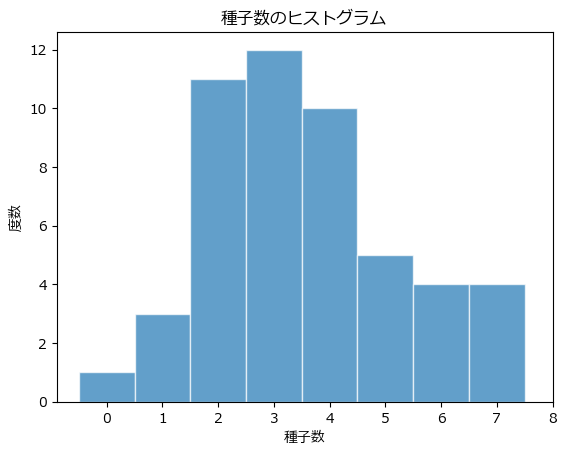

In [10]:
df.plot.hist(
    
    # x軸の調整
    bins=np.arange(-0.5,8),
    xticks=range(9),

    # ヒストグラムの見た目調整
    edgecolor="white",
    alpha=0.7,
    legend=False,
    title="種子数のヒストグラム",
    xlabel="種子数",
    ylabel="度数"
)

この確率分布の特徴(ポアソン分布で特徴を表現できるデータ)
- 非負の整数値
- 平均値と分散が近い
- 単峰性

In [11]:
#分散の確認
print("母分散:", df["種子数"].var(ddof=0))
#不偏分散にしたい場合はn-1で割る、ddof=1を指定 ※デフォルトはddof=1
print("不偏分散:", df["種子数"].var(ddof=1))

母分散: 2.9264000000000006
不偏分散: 2.986122448979592


In [12]:
#標準偏差の確認
print(df["種子数"].std(ddof=0))  # 母標準偏差
print(df["種子数"].std(ddof=1))  # 不偏標準
print(np.sqrt(df["種子数"].var(ddof=1)))  # 不偏標準偏差は分散の平方根でも求まる

1.710672382427448
1.728040060004279
1.728040060004279


# これがポアソン分布だ！
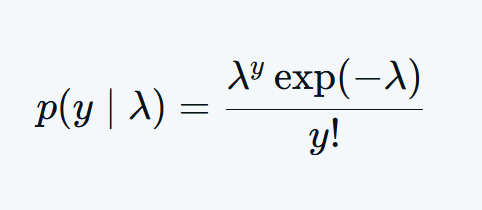

## 基本式を使ってみる

In [13]:
# ポアソン分布の確率質量関数を算出する関数の定義
def poisson_pmf(y, lam):
    return lam**y * np.exp(-lam) / np.array([math.factorial(i) for i in y])
# lamはλ(ラムダ)、yは確率変数の値の配列

In [14]:
# 確率質量関数を計算してみる
y = np.arange(10)  # 確率変数の値の配列
lam =3.5
#確率の算出
poisson_pmf(y, lam)

array([0.03019738, 0.10569084, 0.18495897, 0.21578547, 0.18881229,
       0.1321686 , 0.07709835, 0.03854917, 0.01686526, 0.00655871])

↑3, 4あたりの値が大きいのがわかる。(λ=3.5のあれだから)

In [15]:
#scipy.statsを使って同じ計算
stats.poisson.pmf(y, mu=lam)  # muはλ(ラムダ

array([0.03019738, 0.10569084, 0.18495897, 0.21578547, 0.18881229,
       0.1321686 , 0.07709835, 0.03854917, 0.01686526, 0.00655871])

同じや！

## ポワソン分布を図示してみよう。y=[0,20]の確率を求めてプロットした

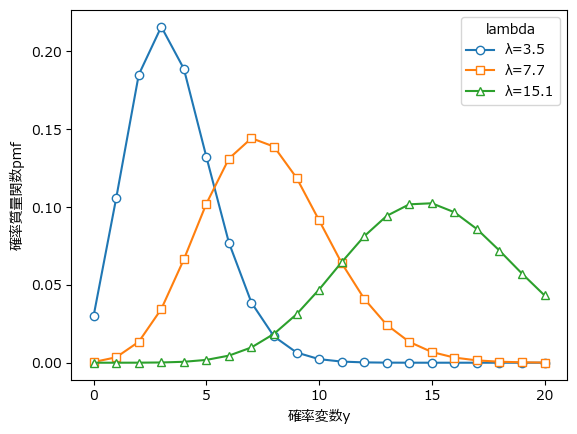

In [16]:
# λの値ごとのポワソン分布
lam_values = [3.5,7.7,15.1]
y = np.arange(21)  # 確率変数の値の配列
marks = ['o', 's', '^']
colors = ['tab:blue', 'tab:orange', 'tab:green']

for lam, mark, color in zip(lam_values, marks, colors):
    pmf_values = stats.poisson.pmf(y, mu=lam)
    plt.plot(y, pmf_values, 
             marker=mark, #markerで指定できるのは'o', 's', '^'などで、マーカーの形状を指定できる。
             mfc="white", # mfcとはmarker face colorの略で、マーカーの塗りつぶし色を指定
             color=color, 
             label=f'λ={lam}')
plt.xlabel('確率変数y')
plt.ylabel('確率質量関数pmf')
plt.xticks(ticks=range(0,21,5)) # x軸の目盛りを0から20まで5刻みで設定
plt.legend(title="lambda")

# ポアソン分布を観測データに当てはめる

## 観測データの平均値(3.56)から予測モデル(ポワソン分布)を作成

In [22]:
df.mean()

種子数    3.56
dtype: float64

In [ ]:
# λ＝df.mean()のポワソン分布を作る
y = np.arange(10)

prob = stats.poisson.pmf(y, mu=df.mean())
display(prob)

array([0.02843882, 0.10124222, 0.18021114, 0.21385056, 0.190327  ,
       0.13551282, 0.08040427, 0.04089132, 0.01819664, 0.00719778])

In [20]:
# 可視化用にprob_dfを作成
prob_df = pd.DataFrame({'y': y, 'prob': prob})
prob_df

,y,prob
0,0,0.028439
1,1,0.101242
2,2,0.180211
3,3,0.213851
4,4,0.190327
5,5,0.135513
6,6,0.080404
7,7,0.040891
8,8,0.018197
9,9,0.007198


<Axes: xlabel='y', ylabel='確率質量関数pmf'>

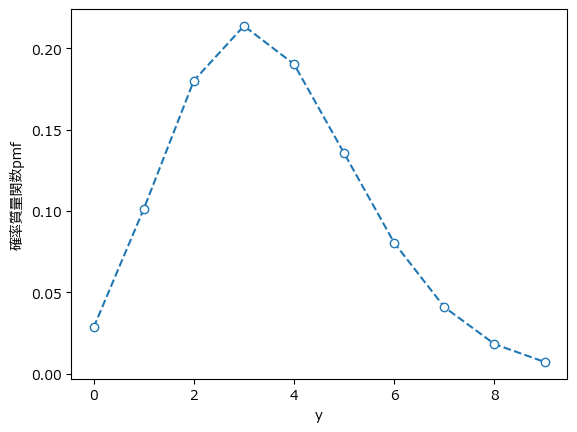

In [21]:
prob_df.plot(
    x='y',
    y='prob',
    marker='o',
    mfc='white',
    ls = "--", # linestyleの略で、線のスタイルを指定。"--"は破線を意味する
    ylabel='確率質量関数pmf',
    legend=False
)

## 観測データの分布と重ねてみる

<Axes: title={'center': '種子数のヒストグラム'}, xlabel='y', ylabel='Frequency'>

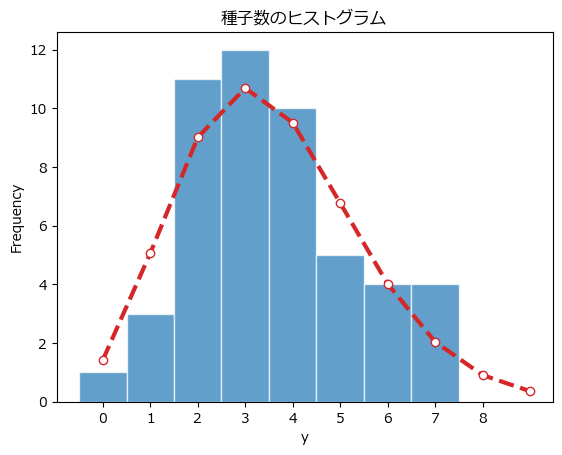

In [23]:
ax = df.plot.hist(
    bins=np.arange(-0.5,8),
    xticks=range(9),
    edgecolor="white",
    color = "tab:blue",
    alpha=0.7, # ヒストグラムの透明度
    legend=False, # 凡例非表示
    title="種子数のヒストグラム",
)

prob_df["pred"] = prob_df["prob"] * len(df)  # 確率を度数に変換
prob_df.plot(
    x='y',
    y='pred',
    marker='o',
    color ='tab:red',
    mfc='white',
    lw=3, # 線の太さを指定
    ls="--",
    legend=False,
    ax=ax  # 既存のaxに重ねる
)

# 最尤推定

## 対数尤度関数の導出

尤度関数
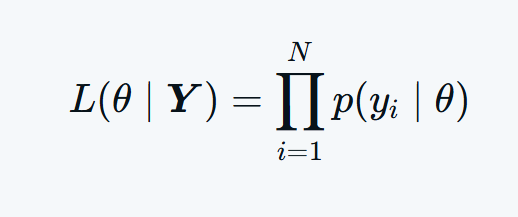

log(p1 × p2× ...)=log(p1) + log(p2) + ...

対数尤度関数
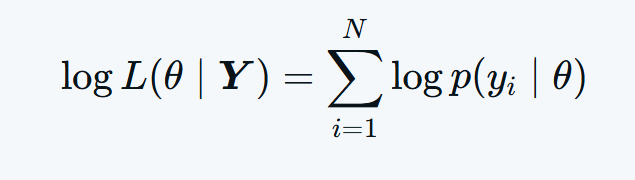  
尤度関数を対数変換した「対数尤度関数」を一般に用いるようです。
確率値の掛け算は非常に小さな値になるため避けたい、とか、「積」を「和」にすることで微分計算がしやすくなることなどが理由

logの積だから

ポアソン分布だとどうなるかな？

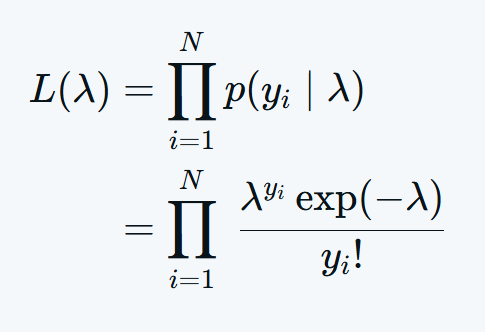

logのルール：
log(ab/c)=log(a)+log(b)-log(c)になるよ  
このルールさえわかればここの変形は余裕

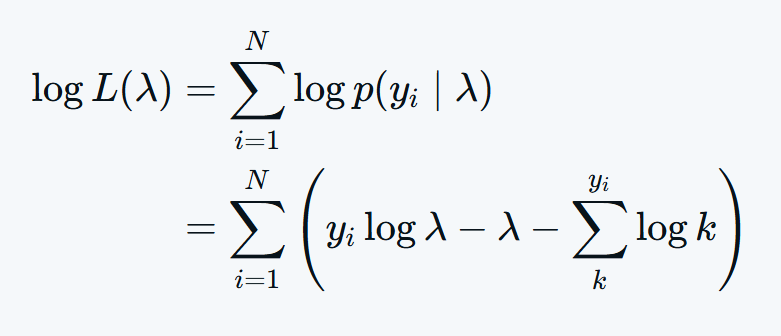

## 試しに実装してみるカァ...

In [25]:
# 自力で実装してみる
def logL(λ, y):
    return sum(yi * np.log(λ) - λ - sum([np.log(k) for k in range(1, yi+1)]) for yi in y) # for yi in yはyの各要素に対して処理を行うイテレーション

logL(3.6, y=df["種子数"])

np.float64(-97.2551554343404)

In [27]:
# scipy.stats利用
np.sum(stats.poisson.logpmf(k=df['種子数'], mu=3.6))

np.float64(-97.25515543434037)

## 実験：データに対しλを変えて尤度(当てはまりの良さ)を試す

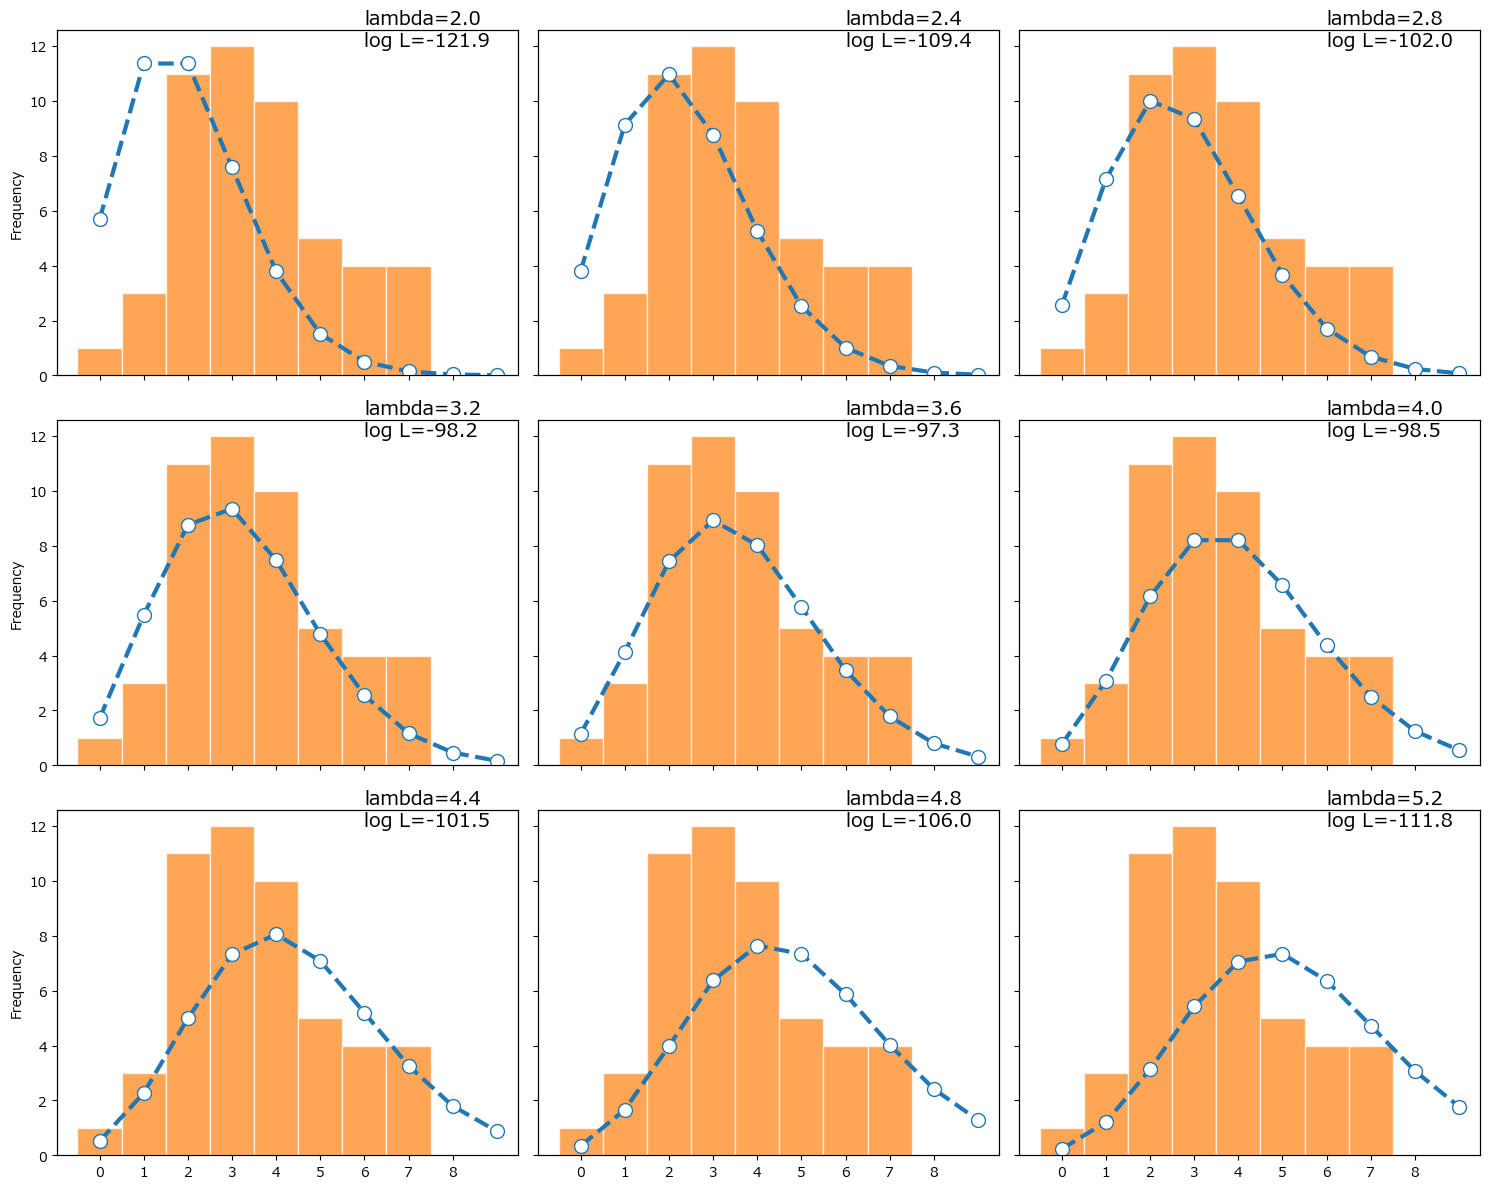

In [ ]:
lams = np.arange(2.0,5.3,0.4) # 2.0から5.2まで0.4刻みでλの値を生成
y = range(10)  # 確率変数の値の配列

# サブプロットの作成, figureとaxesを取得
# 今回のfigureには3x3のサブプロットが含まれ,axesは各サブプロットのAxesオブジェクトを格納した2次元配列になる
fig,axes = plt.subplots(3,3, # 3行3列のサブプロットを作成
                        figsize=(15,12),# サイズ指定, 単位はインチ。使いやすいサイズは15x12くらい
                        tight_layout=True,# レイアウト調整,tight_layout=Trueを指定すると、サブプロット間の重なりを自動的に調整してくれる。もしないと、サブプロット同士が重なって見づらくなることがある。
                        sharex=True, # x軸共有
                        sharey=True  # y軸共有
                        )

for lam,ax in zip(lams, axes.flat): # axes.flatで2次元配列を1次元に変換 この場合、3x3の配列を1x9の配列に変換。
    pmf_values = stats.poisson.pmf(y, mu=lam)
    pmf_df2 = pd.DataFrame({'y': y, 'pmf': pmf_values})
    log_L = np.sum(stats.poisson.logpmf(k=df['種子数'], mu=lam))
    df.plot.hist(
        bins=np.arange(-0.5,8),
        xticks=range(9), # x軸の目盛り
        edgecolor="white", # ヒストグラムの枠線色
        color = "tab:orange", 
        alpha=0.7,
        legend=False,
        ax=ax)
    
    # axとは、各サブプロットのAxesオブジェクトを指す
    # Axesオブジェクトは、matplotlibでグラフを描画するための基本的なコンテナであり、グラフの軸、タイトル、ラベル、データポイントなどを管理します。
    # オブジェクトの構造としては、Figureオブジェクトの中に複数のAxesオブジェクトが含まれる形になります。
    # ax2は、axの右側に共有されたy軸を持つ新しいAxesオブジェクトです。
    ax2 = ax.twinx()  # 右側のy軸を作成
    pmf_df2.plot(
        x='y',
        y='pmf',
        ylim=(0,0.3), # y軸の範囲指定
        marker='o',
        ms=10,  # マーカーサイズ
        lw = 3,
        ls="--",
        mfc='white',
        color='tab:blue',
        legend=False,
        ax=ax2)
    ax2.set_yticks([])  # 右側のy軸の目盛りを非表示
    ax.text(x=6,y=12,s=f"lambda={lam:.1f}\nlog L={log_L:.1f}",fontsize=14) #ax.textは、指定した位置にテキストを追加するためのメソッド

## 対数尤度化数を最小にするλを求めたい

Text(0.5, 1.0, '対数尤度関数-97.244')

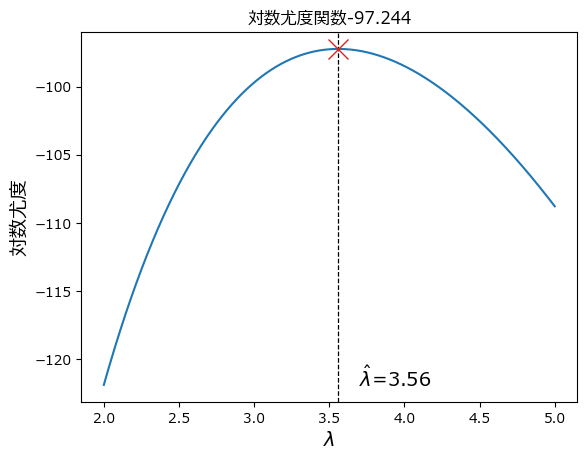

In [31]:
logL = lambda lams,y : np.array([np.sum(stats.poisson.logpmf(k=y, mu=lam)) for lam in lams])
# lambdaは無名関数を定義するキーワード, 無名関数logLはλの配列lamsとデータyを受け取り、各λに対する対数尤度の配列を返す関数

lams = np.linspace(2,5,1001) # 2から5まで1001個の等間隔な値を生成
log_Ls = logL(lams, df['種子数'])
max_idx = log_Ls.argmax()  # 対数尤度が最大となるインデックスを取得

plt.plot(lams, log_Ls)
plt.axvline(lams[max_idx], color='black', ls='--', lw=0.9)  # 最大値の位置に垂直線を引く
plt.plot(lams[max_idx], log_Ls[max_idx], marker='x', color='tab:red', ms=14)  # 最大値の点を赤いマーカーで強調
plt.text(x=3.7, y=-122,s=f"$\hat{{\lambda}}$={lams[max_idx]:.2f}", fontsize=14)  # 最大値のλをテキストで表示
plt.xlabel("$\lambda$", fontsize=14)
plt.ylabel("対数尤度", fontsize=14)
plt.title(f"対数尤度関数{log_Ls[max_idx]:.3f}")

# 標準誤差とは

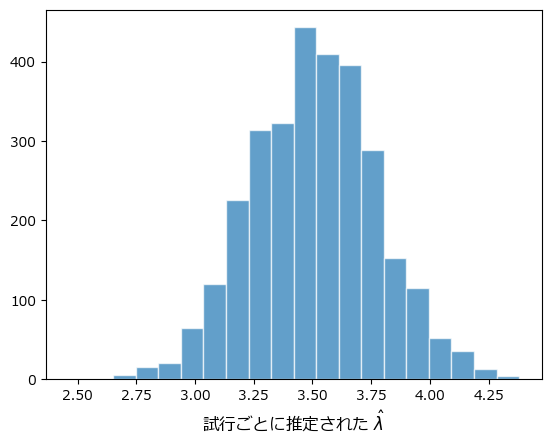

In [33]:
### ポアソン分布の平均λの最尤推定値λ_hatのばらつき p.30 図2.9

# 設定と準備
n = 50               # サンプルサイズ
lam_true = 3.5       # ポアソン分布の平均λ
iter = 3000          # シミュレーション回数
rng = np.random.default_rng(seed=123)  # 乱数生成器
samples = []         # λ_hatを格納するリストの初期化

# λの最尤推定を3000回繰り返す
for _ in range(iter):  # ポアソン分布のλの最尤推定値が標本平均であることを利用
    lam_hat = stats.poisson.rvs(mu=lam_true, size=n, random_state=rng).mean()
    samples.append(lam_hat)

# ヒストグラムの描画
plt.hist(samples, bins=20, edgecolor='white', alpha=0.7)
plt.xlabel('試行ごとに推定された $\hat{\lambda}$', fontsize=12);

In [ ]:
# シミュレーションに基づく最尤推定値の標準誤差
print(f'最尤推定値の標準誤差: {np.std(samples, ddof=1):.4f}')

最尤推定値の標準誤差: 0.2659


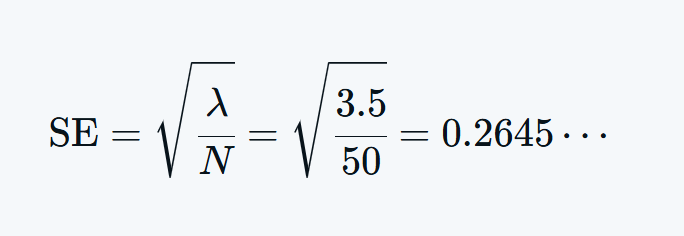

## 真のλがわかっていれば、標準誤差がわかる(↑の3000回やったときの標本側のλのばらつき)

## 観測データから標準誤差を求めるときは、標本λでやってみる。

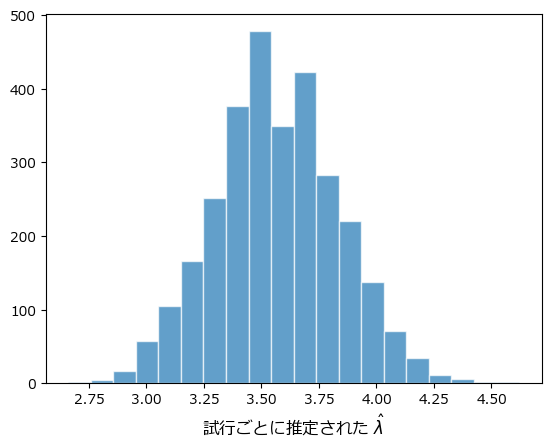

In [36]:
# λ=3.56だったよね。

### ポアソン分布の平均λの最尤推定値λ_hatのばらつき 最尤推定値で計算

# 設定と準備
n = 50               # サンプルサイズ
lam_llf = 3.56       # ポアソン分布の平均λの最尤推定値
iter = 3000          # シミュレーション回数
rng = np.random.default_rng(seed=123)  # 乱数生成器
samples2 = []         # λ_hatを格納するリストの初期化

# λの最尤推定を3000回繰り返す
for _ in range(iter):  # ポアソン分布のλの最尤推定値が標本平均であることを利用
    lam_hat = stats.poisson.rvs(mu=lam_llf, size=n, random_state=rng).mean()
    samples2.append(lam_hat)

# ヒストグラムの描画
plt.hist(samples2, bins=20, edgecolor='white', alpha=0.7)
plt.xlabel('試行ごとに推定された $\hat{\lambda}$', fontsize=12);

In [ ]:
# シミュレーションに基づく最尤推定値の標準誤差
print(f'最尤推定値の標準誤差: {np.std(samples2, ddof=1):.4f}')

最尤推定値の標準誤差: 0.2668


: 

### さっきよりちょっと大きくなったね、でも算出できた！！

### AICを使えばもっといいモデルが作れるよ、それは4章のお楽しみ